In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

Definiere Zufallsvariable für Replizierbarkeit

In [2]:
random_variable = 1234

#### Nutze ";" als Trennzeichen: 
data_a = pd.read_csv('churn_part_a.csv', delimiter = ';')

In [3]:
data_a = pd.read_csv('churn_part_a.csv')

In [4]:
data_a.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0


In [5]:
data_b = pd.read_csv('churn_part_b.csv')

In [6]:
data_b.head()

,CustomerId,Geography,Gender,Age
0,15634602,France,Female,42.0
1,15647311,Spain,Female,NaN
2,15619304,France,Female,42.0
3,15701354,France,Female,39.0
4,15737888,Spain,Female,43.0


### Combine Datasets
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.merge.html

In [7]:
data = pd.merge(data_a, data_b, how='inner', on='CustomerId')

In [8]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0
1,2,15647311,Hill,608,1,83807.86,1,0,1,112542.58,0,Spain,Female,NaN
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0


In [9]:
data.shape

(10000, 14)

In [10]:
data_a.shape

(10000, 11)

In [11]:
data_b.shape

(10000, 4)

### %-Anteil der Kunden die uns verlassen haben

In [12]:
data["Exited"].sum()/data.shape[0]

np.float64(0.2037)

### Ermittle Anzahl vollständiger Datensätze

In [13]:
data.dropna(axis=0).shape

(9996, 14)

### "Entferne"  Zeilen, in denen entweder Gender oder Age oder Beides NaN ist

In [14]:
data.dropna(axis=0, subset=['Gender', 'Age']).shape

(9997, 14)

In [ ]:
data.shape

(10000, 14)

In [ ]:
### Erstelle Datensatz in dem die Zeilen mit NaNs entfernt wurden

In [15]:
data_cleaned = data.dropna(axis=0)

In [16]:
data_cleaned.shape

(9996, 14)

### Visuelle Analyse

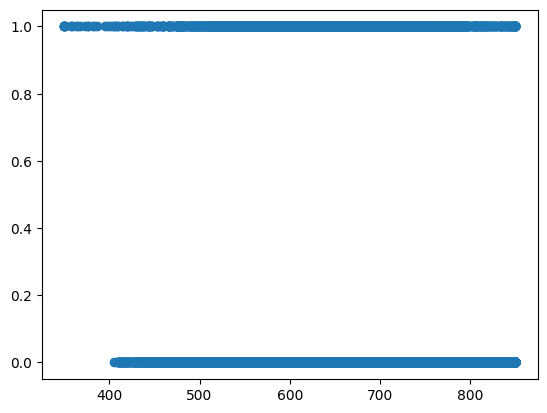

In [17]:
plt.scatter(data_cleaned['CreditScore'], data_cleaned['Exited'])

In [ ]:
data_cleaned.groupby('Exited')['CreditScore'].mean()

Exited
0    651.844598
1    645.347741
Name: CreditScore, dtype: float64

In [ ]:
data_cleaned.groupby('Exited')['Age'].mean()

Exited
0    37.410427
1    44.831532
Name: Age, dtype: float64

In [ ]:
data_cleaned.groupby('Exited')['Age'].min()

Exited
0    18.0
1    18.0
Name: Age, dtype: float64

### Überblick über Churn Altersgruppen

/var/folders/2t/qqms9sv564dfb0p55s5xfyy00000gn/T/ipykernel_82400/3368007567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age = data_cleaned.groupby('Age_Group')['Exited'].mean()


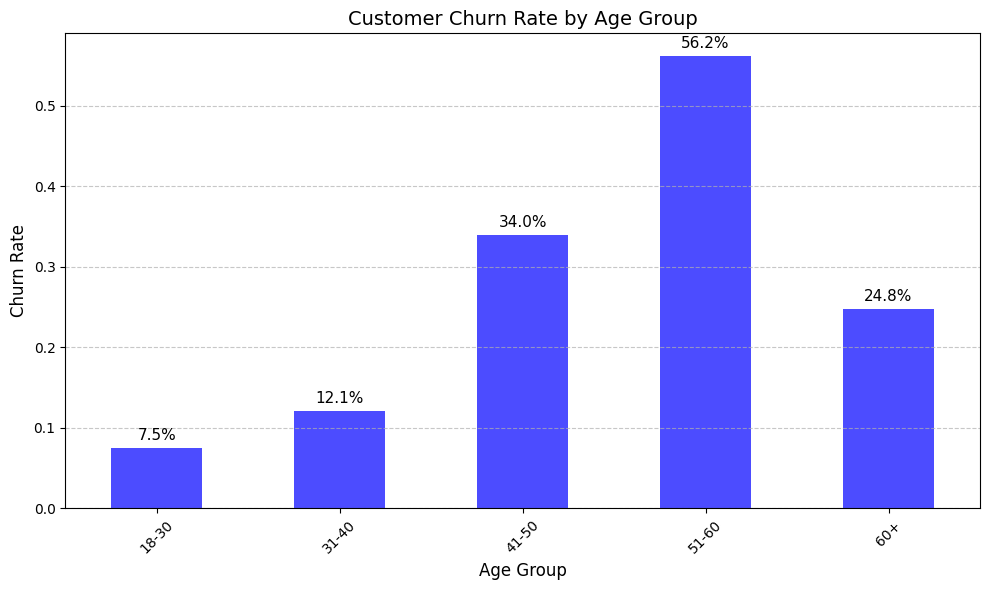

In [23]:
# Create age groups and analyze churn by age
# First, let's create age groups
data_cleaned.loc[:, 'Age_Group'] = pd.cut(
        data_cleaned['Age'], 
        bins=[17, 30, 40, 50, 60, 100], 
        labels=['18-30', '31-40', '41-50', '51-60', '60+']
        )

# Calculate churn rate for each age group
churn_by_age = data_cleaned.groupby('Age_Group')['Exited'].mean()

# Create the bar chart
plt.figure(figsize=(10, 6))
churn_by_age.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Customer Churn Rate by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of each bar
for i, value in enumerate(churn_by_age):
    plt.text(i, value + 0.01, f'{value:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/2t/qqms9sv564dfb0p55s5xfyy00000gn/T/ipykernel_82400/3228021993.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = data_cleaned.groupby('Age_Group').agg(


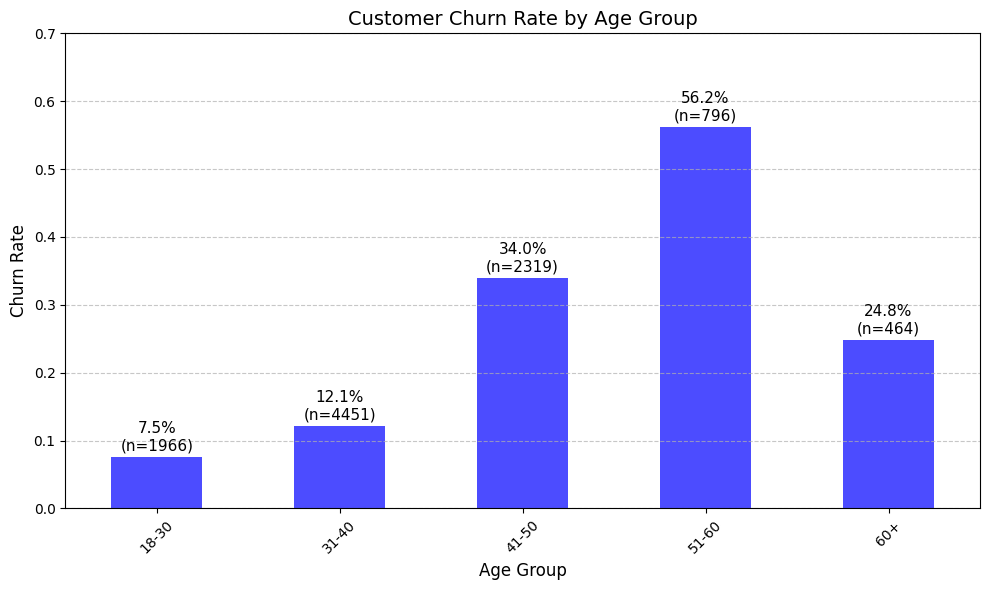

In [25]:
# Create age groups and analyze churn by age with counts
data_cleaned.loc[:, 'Age_Group'] = pd.cut(
        data_cleaned['Age'], 
        bins=[17, 30, 40, 50, 60, 100], 
        labels=['18-30', '31-40', '41-50', '51-60', '60+']
        )

# Calculate churn rate and counts for each age group
age_group_stats = data_cleaned.groupby('Age_Group').agg(
    churn_rate=('Exited', 'mean'),
    count=('Exited', 'count')
)

# Create the bar chart
plt.figure(figsize=(10, 6))
age_group_stats['churn_rate'].plot(kind='bar', color='blue', alpha=0.7)
plt.title('Customer Churn Rate by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.ylim(0, 0.7)  # Sets y-axis to range from 0 to 0.5 (or 50%)

# Add percentage labels and counts on top of each bar
for i, (rate, count) in enumerate(zip(age_group_stats['churn_rate'], age_group_stats['count'])):
    plt.text(i, rate + 0.01, f'{rate:.1%}\n(n={count})', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### 1. Vorhersagemodel: Logistische Regression

### Selektiere Features (Variablen die für die Vorhersage genutzt werden)

In [26]:
x = data_cleaned[['Age', 'CreditScore', 'Balance']]

In [28]:
log_reg_simple = LogisticRegression(random_state=random_variable)

In [29]:
log_reg_simple.fit(x, data_cleaned['Exited'])

LogisticRegression(random_state=1234)

In [30]:
log_reg_simple.coef_

array([[ 6.33155132e-02, -7.71750832e-04,  5.02711176e-06]])

### Zeige Koeffizienten formatiert an

In [32]:
coefficients_formated =  pd.concat(
    [
     pd.Series(['Age', 'CreditScore', 'Balance']),
     pd.DataFrame(np.transpose(log_reg_simple.coef_))
    ],
     axis=1
 )

In [33]:
coefficients_formated

,0,0
0,Age,0.063316
1,CreditScore,-0.000772
2,Balance,0.000005


### Berechne Wahrscheinlichkeit dass uns ein Kunden verlässt (Exited = 1)

In [34]:
log_reg_simple.predict_proba(x)

array([[0.84242597, 0.15757403],
       [0.68642596, 0.31357404],
       [0.87303642, 0.12696358],
       ...,
       [0.89338001, 0.10661999],
       [0.80487652, 0.19512348],
       [0.8851447 , 0.1148553 ]])

jeder Kunde erhählt eine Wahrscheinlichkeit dass er bei uns bleibt (Exited=0) und eine dass er uns verlässt (Exited=1)

### Vorhersage ob Kunden uns verlässt (1) oder bei uns bleibt (0), jede Zahl repräsentiert einen Kunden


In [35]:
log_reg_simple.predict(x)

array([0, 0, 0, ..., 0, 0, 0])

### Berechnung Confusion Matrix

In [36]:
predictions = log_reg_simple.predict(x)

confusion_matrix(beboachtete Werte, vorhergesagte Werte, Sortierung)

In [37]:
cnf_matrix = metrics.confusion_matrix(
                    data_cleaned['Exited'], 
                    predictions, 
                    labels = [True, False]
                )

In [38]:
cnf_matrix

array([[ 125, 1911],
       [ 286, 7674]])

In [39]:
accuracy = (113 + 7779)/(113 + 1923 + 181 + 7779)

In [40]:
accuracy

0.789515806322529

In [41]:
precision = 113/(113 + 181)

In [42]:
precision

0.3843537414965986

### Model with more variables

In [44]:
data_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0


In [45]:
x = data_cleaned[['Age', 'CreditScore', 'Balance', 'EstimatedSalary']]

In [46]:
log_reg_simple = LogisticRegression(random_state=random_variable)

In [47]:
log_reg_simple.fit(x, data_cleaned['Exited'])

LogisticRegression(random_state=1234)

In [48]:
log_reg_simple.coef_

array([[ 4.34627882e-02, -5.03045238e-03,  3.62329569e-06,
        -1.34978002e-06]])

In [49]:
predictions = log_reg_simple.predict(x)

In [50]:
cnf_matrix = metrics.confusion_matrix(
                    data_cleaned['Exited'], 
                    predictions, 
                    labels = [True, False]
                )

In [51]:
cnf_matrix

array([[ 112, 1924],
       [ 176, 7784]])

In [52]:
112/(112+ 176)

0.3888888888888889

### Berechnung Accuracy mit implementierter Lösung

In [53]:
metrics.accuracy_score(data_cleaned['Exited'], 
                    predictions)

0.7899159663865546

### Berechnung Precision mit implementierter Lösung

In [54]:
metrics.precision_score(data_cleaned['Exited'], 
                    predictions)

0.3888888888888889

### Erzeugen von Spalte die den Wert True bei Frauen animmt und False bei Männern

In [43]:
data_cleaned['Gender_Boolean'] = data['Gender'] == 'Female'

/var/folders/5w/c6f6wm9j6_zdtlzdfqck5lm80000gn/T/ipykernel_77143/2184254904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Gender_Boolean'] = data['Gender'] == 'Female'


In [44]:
data_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age,Gender_Boolean
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0,True
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0,True
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0,True
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0,True
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0,False


### Umwandeln in Zahl

In [45]:
data_cleaned['Gender_numeric'] = data_cleaned['Gender_Boolean'].astype(int)

/var/folders/5w/c6f6wm9j6_zdtlzdfqck5lm80000gn/T/ipykernel_77143/1977041434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Gender_numeric'] = data_cleaned['Gender_Boolean'].astype(int)


In [46]:
data_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age,Gender_Boolean,Gender_numeric
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0,True,1
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0,True,1
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0,True,1
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0,True,1
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0,False,0


In [47]:
data_cleaned['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

### Generierung Dummy Encoding für die Spalte Geography

In [48]:
geography_dummies = pd.get_dummies(data_cleaned['Geography'], prefix="g")

In [49]:
geography_dummies

,g_France,g_Germany,g_Spain
0,True,False,False
2,True,False,False
3,True,False,False
4,False,False,True
5,False,False,True
...,...,...,...
9995,True,False,False
9996,True,False,False
9997,True,False,False
9998,False,True,False


### Mergen von data_cleaned und geography_dummies (Spalten zu data_cleaned hinzfügen)

In [50]:
data_full = pd.concat([data_cleaned, geography_dummies], axis=1)

In [51]:
data_full

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age,Gender_Boolean,Gender_numeric,g_France,g_Germany,g_Spain
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0,True,1,True,False,False
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0,True,1,True,False,False
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0,True,1,True,False,False
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0,True,1,False,False,True
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0,False,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,5,0.00,2,1,0,96270.64,0,France,Male,39.0,False,0,True,False,False
9996,9997,15569892,Johnstone,516,10,57369.61,1,1,1,101699.77,0,France,Male,35.0,False,0,True,False,False
9997,9998,15584532,Liu,709,7,0.00,1,0,1,42085.58,1,France,Female,36.0,True,1,True,False,False
9998,9999,15682355,Sabbatini,772,3,75075.31,2,1,0,92888.52,1,Germany,Male,42.0,False,0,False,True,False


### Neues Modell mit Herkunftsland und Geschlecht

In [52]:
x_full = data_full[['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Gender_numeric',
                 'g_Spain', 'g_Germany']]

In [54]:
log_reg_simple = LogisticRegression(random_state=random_variable)

In [55]:
log_reg_simple.fit(x_full, data_full['Exited'])

/Users/jan/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=1234)

In [56]:
predictions_full = log_reg_simple.predict(x_full)

In [57]:
cnf_matrix = metrics.confusion_matrix(
                    data_full['Exited'], 
                    predictions_full, 
                    labels = [True, False]
                )

In [58]:
cnf_matrix

array([[ 227, 1809],
       [ 244, 7716]])

In [59]:
metrics.accuracy_score(data_full['Exited'], 
                    predictions_full)

0.7946178471388555

In [60]:
metrics.precision_score(data_full['Exited'], 
                    predictions_full)

0.4819532908704883

In [61]:
coefficients_formated =  pd.concat(
    [
     pd.Series(['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Gender_numeric',
                 'g_Spain', 'g_Germany']),
     pd.DataFrame(np.transpose(log_reg_simple.coef_))
    ],
     axis=1
 )

In [62]:
coefficients_formated

,0,0
0,Age,0.044184
1,CreditScore,-0.004939
2,Balance,0.000002
3,EstimatedSalary,-0.000001
4,Gender_numeric,0.512734
5,g_Spain,-0.286643
6,g_Germany,0.639685


### Decision Tree

In [63]:
from sklearn import tree

Entscheidungsbaum mit 3 Leveln (Depth)

In [64]:
clf_tree = tree.DecisionTreeClassifier(random_state=random_variable, max_depth=3)

Entscheidungsbaum mit 20 Leveln (Depth)

In [65]:
clf_tree = tree.DecisionTreeClassifier(random_state=random_variable, max_depth=20)

### Baum auf Daten anpassen (Trainieren)

In [66]:
clf_tree.fit(x_full, data_full['Exited'])

DecisionTreeClassifier(max_depth=20, random_state=1234)

### Erzeugen von Vorhersagen

In [67]:
predictions_tree = clf_tree.predict(x_full)

In [68]:
cnf_matrix_tree = metrics.confusion_matrix(
                    data_full['Exited'], 
                    predictions_tree, 
                    labels = [True, False]
                )

In [69]:
cnf_matrix_tree

array([[1878,  158],
       [  42, 7918]])

In [70]:
metrics.accuracy_score(data_full['Exited'], 
                    predictions_tree)

0.9799919967987195

In [71]:
metrics.precision_score(data_full['Exited'], 
                    predictions_tree)

0.978125

### Entscheigunsbaum darstellen

[Text(0.6337919176701777, 0.9761904761904762, 'Age <= 42.5\ngini = 0.324\nsamples = 9996\nvalue = [7960.0, 2036.0]'),
 Text(0.38970733258832774, 0.9285714285714286, 'Age <= 38.5\ngini = 0.207\nsamples = 7103\nvalue = [6271, 832]'),
 Text(0.5117496251292527, 0.9523809523809523, 'True  '),
 Text(0.2522491616172589, 0.8809523809523809, 'g_Germany <= 0.5\ngini = 0.171\nsamples = 5562\nvalue = [5037, 525]'),
 Text(0.18590148189723618, 0.8333333333333334, 'Balance <= 181138.281\ngini = 0.14\nsamples = 4294\nvalue = [3969, 325]'),
 Text(0.10563412983884812, 0.7857142857142857, 'CreditScore <= 410.5\ngini = 0.134\nsamples = 4234\nvalue = [3928, 306]'),
 Text(0.05056381700356208, 0.7380952380952381, 'Gender_numeric <= 0.5\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.049877151195227676, 0.6904761904761905, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.05125048281189649, 0.6904761904761905, 'g_Spain <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.05056381700356208, 0.6428

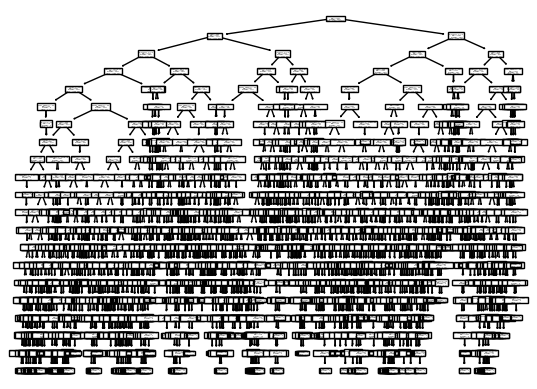

In [72]:
tree.plot_tree(clf_tree, feature_names=x_full.columns)

Installation von Graphviz um optisch schöneren Entscheidungsbaum zu generieren, Installer von hier runterladen:
https://elearning.ohmportal.de/mod/url/view.php?id=511080

im zweiten Schritt für Python installieren


In [84]:
!pip install graphviz

In [73]:
import graphviz

In [74]:
dot_data = tree.export_graphviz(clf_tree, feature_names=x_full.columns, filled=True, out_file=None)

In [75]:
graph = graphviz.Source(dot_data)

### Graph anzeigen

In [ ]:
graph

In [76]:
graph.render("churn_tree", format="png", cleanup=True)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.353913 to fit


'churn_tree.png'

In [89]:
metrics.accuracy_score(data_full['Exited'], 
                    predictions_tree)

0.9799919967987195

- sehr hohe Accuracy, aber Baum passt sich sehr auf die Daten (Overfitting)
- Baum wird bei neuen Daten nicht mehr so gut funktionen

### Random Forest
Rechne verschiedene Bäume und nutze die durchschnittliche Wahrscheinlichtkeit als Vorhersage

### Random Forest für den wir festlegen, dass in jedem Blatt/Gruppe mindestens 20 Beobachtungen sein müssen (parameter: min_samples_leaf)

In [91]:
rf = RandomForestClassifier(random_state = random_variable, min_samples_leaf=20)

In [92]:
rf.fit(x_full, data_full['Exited'])

RandomForestClassifier(min_samples_leaf=20, random_state=1234)

In [93]:
predictions_rf = rf.predict(x_full)

In [94]:
cnf_rf = metrics.confusion_matrix(data_full['Exited'], predictions_rf, labels=[True, False])

In [95]:
cnf_rf

array([[ 621, 1415],
       [ 203, 7757]])

## Gradient Boosting

In [91]:
gbm = GradientBoostingClassifier(random_state = random_variable, n_estimators=100)

In [102]:
gbm.fit(x_full, data_full['Exited'])

GradientBoostingClassifier(random_state=1234)

In [104]:
predictions_gbm = gbm.predict(x_full)

In [106]:
cnf_gbm = metrics.confusion_matrix(data_full['Exited'], predictions_gbm, labels=[True, False])

In [107]:
cnf_gbm

array([[ 685, 1351],
       [ 294, 7666]])

# Test / Train Split

In [77]:
from sklearn.model_selection import train_test_split


In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    x_full, 
    data_full['Exited'], 
    test_size=0.2, 
    random_state=random_variable,
    stratify=data_full['Exited']  # Maintain the same class distribution in train and test
)


In [93]:
gbm.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1234)

In [94]:
predictions_gbm = gbm.predict(X_test)

In [95]:
metrics.confusion_matrix(y_test, predictions_gbm, labels=[True, False])

array([[ 138,  269],
       [  71, 1522]])

In [ ]:
metrics.confusion_matrix(y_test, predictions_gbm, labels=[True, False])

In [96]:
metrics.accuracy_score(y_test, predictions_gbm)
         

0.83

# Grid Search

In [ ]:
# Define parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [81]:
# Create base GBM model
gbm_grid = GradientBoostingClassifier(random_state=random_variable)


In [83]:

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=gbm_grid,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
    )

In [84]:


# Fit the grid search
grid_search.fit(x_full, data_full['Exited'])


Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=1234),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [85]:

# Get best parameters and best estimator
print("Best parameters:", grid_search.best_params_)
best_gbm = grid_search.best_estimator_



Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [86]:
# Make predictions with best model
predictions_best_gbm = best_gbm.predict(x_full)


In [87]:

# Evaluate results
cnf_best_gbm = metrics.confusion_matrix(data_full['Exited'], predictions_best_gbm, labels=[True, False])
print("Confusion Matrix for Best GBM:")
print(cnf_best_gbm)
print("Accuracy:", metrics.accuracy_score(data_full['Exited'], predictions_best_gbm))
print("Precision:", metrics.precision_score(data_full['Exited'], predictions_best_gbm))

Confusion Matrix for Best GBM:
[[ 699 1337]
 [ 276 7684]]
Accuracy: 0.8386354541816726
Precision: 0.7169230769230769
